In [ ]:
# Importing required libraries
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import imageio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from numba import njit
import sys

In [ ]:
# Defining variables and arrays

def setup() : 
    # Grid
    dx = 0.01
    dy = 0.01
    Lx = 2
    Ly = 1

    Nx = int(Lx/dx+1)
    Ny = int(Ly/dy+1)
    dx2 = dx**2
    dy2 = dy**2

    # Time
    t_end = 1
    dt = 0.001
    n_steps = int(t_end/dt)

    # Create grid
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X,Y = np.meshgrid(x, y)

    # Create shape
    shape, ref_length = set_shape(X,Y,Lx,Ly) # ref length is chord 

    # Flow parameters
    U_inf = 0.5
    Re = 100
    # i.e flow velocity and kin_viscosity is governed by Re
    kin_viscosity = U_inf*ref_length/Re

    # checking CFL convergence : 
    if U_inf*dt/dx >= 1 : 
        sys.exit("Stability is not guaranteed due CFL convergence ") 

    # CFL convergence is guaranteed in v as smaller than u 

    # checking viscosity convergence : 
    if dx2/(2*kin_viscosity) <= dt : 
        sys.exit("Stability is not guaranteed due to viscosity convergence")

    # Gauss-Seidel pressure solver parameters
    denominator = 2*(dx2+dy2)
    relaxation = 1.8 # SOR relaxation
    tolerance = 10**(-3) # pressure change tolerance
    max_iterations = 50000

    #  Initialization
    u = np.zeros((Ny, Nx))
    v = np.zeros((Ny, Nx))
    p = np.zeros((Ny, Nx))
    u[shape] = 0 
    v[shape] = 0
    u, v = apply_velocity_BC(u, v, U_inf)

    return p,u,v,U_inf,dx,dy,dx2,dy2,dt,denominator,Nx,Ny,X,Y,ref_length,kin_viscosity,shape,relaxation,tolerance,max_iterations,n_steps

In [ ]:
# Setting the boundary conditions/initial values

def apply_velocity_BC(u,v,U_inf) : 
    # Dirichlet at inlet : 
    u[:,0] = U_inf
    v[:,0] = 0

    # Neumann at outlet : 
    u[:,-1] = u[:,-2]
    v[:,-1] = v[:,-2]

    # Neumann at top and bottom to simualte "free stream"
    # Excluding the edges already set by inlet and outlet BC to not overwrite. 
    u[0,1:-1] = u[1,1:-1]
    u[-1,1:-1] = u[-2,1:-1]
    v[0,1:-1] = v[1,1:-1]
    v[-1,1:-1] = v[-2,1:-1]

    return u,v

In [ ]:
# Implementing the numerical method

@njit
def pressure_solver(p, div_source, dx2, dy2, Nx, Ny, shape, relaxation, tolerance, max_iterations):
    for iteration in range(max_iterations):
        # Gauss-Seidl sweep
        max_change = 0 # for convergence check
        max_p = 0 # for percentage convergence
        for j in range(1,Ny-1):
            for i in range(1,Nx-1):
                p_old = p[j,i]

                if shape[j,i]: # Neumann for pressure along shape to avoid inexistent pressure gradients (dp/dn = 0)
                    # assume edge of shape pressure is average of surrounding fluid pressure
                    p_sum = 0.0
                    n_count = 0
                    if not shape[j,i+1]: p_sum += p[j,i+1]; n_count += 1 
                    if not shape[j,i-1]: p_sum += p[j,i-1]; n_count += 1
                    if not shape[j+1,i]: p_sum += p[j+1,i]; n_count += 1
                    if not shape[j-1,i]: p_sum += p[j-1,i]; n_count += 1
                    if n_count > 0:
                        p[j,i] = p_sum / n_count
                else: # Only for fluid cells

                    p_sum = 0
                    coeff = 0
                    # Exclude solid neighbours from sum and coefficient as not representative of flow
                    if not shape[j,i+1]: p_sum += dy2 * p[j,i+1]; coeff += dy2
                    if not shape[j,i-1]: p_sum += dy2 * p[j,i-1]; coeff += dy2
                    if not shape[j+1,i]: p_sum += dx2 * p[j+1,i]; coeff += dx2
                    if not shape[j-1,i]: p_sum += dx2 * p[j-1,i]; coeff += dx2

                    # SOR for faster Gauss-Seidel convergence
                    p_intermediate = (p_sum - dx2*dy2*div_source[j,i])/coeff
                    p[j, i] = relaxation*p_intermediate + (1-relaxation)*p_old 
                
                error = abs(p[j,i]-p_old)
                if error >= max_change : 
                    max_change = error  
                if abs(p[j,i]) >= max_p : 
                    max_p = abs(p[j,i])
        
        # Apply boundary conditions
        # Top and bottom walls: Neumann
        for i in range(Nx):
            p[0,i] = p[1,i]
            p[Ny-1,i] = p[Ny-2,i]
        
        # Inlet: Neumann
        for j in range(Ny):
            p[j,0] = p[j,1]
        
        # Outlet: Dirichlet (p = 0)
        for j in range(Ny):
            p[j,Nx-1] = 0
            
        # percentage error for convergence check : 
        if (max_change/(abs(max_p+1.0e-10))) <= tolerance : # 10^-10 is to ensure no division by zero
            return p, iteration
    
    return p, max_iterations

@njit
def compute_advection(u,v,dx,dy,Nx,Ny,shape) : # Advection : (u·∇)u
    adv_u = np.zeros((Ny,Nx))
    adv_v = np.zeros((Ny,Nx))

    for j in range(1,Ny-1) : 
        for i in range(1,Nx-1) : 
            if shape[j,i] : 
                continue

            # Compute derivatives using Upwind difference to ensure stability at higher Re (because upwind flow is always more stable)
            # (∂u/∂x, ∂u/∂y, ∂v/∂x, ∂v/∂y)
            dudx = ((u[j,i] - u[j,i-1])/(dx)) if u[j,i] > 0 else ((u[j,i+1] - u[j,i])/(dx))
            dudy = ((u[j,i] - u[j-1,i])/(dy)) if v[j,i] > 0 else ((u[j+1,i] - u[j,i])/(dy))
            dvdx = ((v[j,i] - v[j,i-1])/(dx)) if u[j,i] > 0 else ((v[j,i+1] - v[j,i])/(dx))
            dvdy = ((v[j,i] - v[j-1,i])/(dy)) if v[j,i] > 0 else ((v[j+1,i] - v[j,i])/(dy))

            # (u·∇)u = u*(∂u/∂x) + v*(∂u/∂y)
            adv_u[j,i] = u[j,i]*dudx + v[j,i]*dudy
            
            # (u·∇)v = u*(∂v/∂x) + v*(∂v/∂y)
            adv_v[j,i] = u[j,i]*dvdx + v[j,i]*dvdy
    
    return adv_u, adv_v

@njit
def compute_Laplacian(u,v,dx2,dy2,Nx,Ny,shape) : # Laplacian : ∇²u 
    Lap_u = np.zeros((Ny,Nx))
    Lap_v = np.zeros((Ny,Nx)) 

    for j in range(1,Ny-1) : 
        for i in range(1,Nx-1) : 
            if shape[j,i] : 
                continue 
            
            # Laplacian of u: ∇²u = ∂²u/∂x² + ∂²u/∂y², using Central Difference
            Lap_u[j,i] = (u[j, i+1] - 2*u[j, i] + u[j, i-1])/dx2 + (u[j+1, i] - 2*u[j, i] + u[j-1, i])/dy2
            Lap_v[j,i] = (v[j, i+1] - 2*v[j, i] + v[j, i-1])/dx2 + (v[j+1, i] - 2*v[j, i] + v[j-1, i])/dy2

    return Lap_u,Lap_v

@njit
def compute_divergence(u,v,dx,dy,Nx,Ny,shape) : # Divergence : ∇·u
    div = np.zeros((Ny,Nx))

    for j in range(1,Ny-1) :
        for i in range(1,Nx-1) : 
            if shape[j,i] : 
               continue 

            # Computing derivatives (∂u/∂x, ∂v/∂y)
            dudx = (u[j,i+1] - u[j,i])/(dx) # Forward difference
            dvdy = (v[j+1,i] - v[j,i])/(dy) # Forward difference
           
            # Calculating Divergence (∇·u = ∂u/∂x + ∂v/∂y)
            div[j,i] = dudx + dvdy

    return div

@njit
def compute_pressure_gradient(p,dx,dy,Nx,Ny,shape): # Gradient : ∇p
    # Initialising ∂p/∂x and ∂p/∂y
    dpdx = np.zeros((Ny, Nx))
    dpdy = np.zeros((Ny, Nx))
    
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            if shape[j,i]:
                continue
            dpdx[j,i] = (p[j,i] - p[j,i-1])/(dx)
            dpdy[j,i] = (p[j,i] - p[j-1,i])/(dy)
    
    return dpdx, dpdy

@njit
def predict_velocity(u,v,dx,dy,dx2,dy2,dt,Nx,Ny,kin_viscosity,shape) : # Inital guess at velocity neglecting pressure field
    adv_u, adv_v = compute_advection(u,v,dx,dy,Nx,Ny,shape)
    Lap_u,Lap_v = compute_Laplacian(u,v,dx2,dy2,Nx,Ny,shape) 

    # Explicit Euler-Steps : 
    u_star = u + dt*(-adv_u + kin_viscosity*Lap_u)
    v_star = v + dt*(-adv_v + kin_viscosity*Lap_v)

    # Setting velocity as 0 inside shape
    for j in range(Ny):
        for i in range(Nx):
            if shape[j,i]:
                u_star[j,i] = 0
                v_star[j,i] = 0

    return u_star, v_star

@njit
def compute_pressure_correction(p,u_star,v_star,dx,dy,dx2,dy2,dt,Nx,Ny,shape,relaxation,tolerance,max_iterations) : # Compute pressure of field with predicted velocity
    div_u_star = compute_divergence(u_star,v_star,dx,dy,Nx,Ny,shape) 
    div_source = div_u_star/dt

    p_new, num_iterations = pressure_solver(p,div_source,dx2,dy2,Nx,Ny,shape,relaxation,tolerance,max_iterations)

    return p_new, num_iterations

@njit
def velocity_correction(p,u_star,v_star,dx,dy,dt,Nx,Ny,shape) : # calculates divergence free velocity field 
    dpdx, dpdy = compute_pressure_gradient(p,dx,dy,Nx,Ny,shape)
    u_final = u_star - dt*dpdx
    v_final = v_star - dt*dpdy

    for j in range(Ny):
        for i in range(Nx):
            if shape[j, i]:
                u_final[j, i] = 0
                v_final[j, i] = 0


    return u_final,v_final

def set_shape(X,Y,Lx,Ly) : # creating solid shape
    
    def cylinder(X,Y,Lx,Ly) : 
        #cylinder parameters
        cylinder_x = 0.4*Lx  # x center is 40% from left
        cylinder_y = 0.5*Ly   # y center is 50% from bottom
        cylinder_radius = 0.2*Ly # radius is 20% of domain length

        cylinder = (X-cylinder_x)**2 + (Y-cylinder_y)**2 <= cylinder_radius**2 # returns array with True when inside cylinder, and False outside

        return cylinder, 2*cylinder_radius # diameter is ref_length
    
    def wing(X,Y,Lx,Ly) : 
        #wing parameters
        x_le = 0.15*Lx
        chord = 0.4*Lx
        thickness = 0.2*Ly
        angle = 10

        y_center = Ly/2

        x_mid = x_le + chord/2
        y_mid = y_center

        Xr = X - x_mid
        Yr = Y - y_mid

        alpha = np.deg2rad(-angle)

        Xrot = Xr*np.cos(alpha) + Yr*np.sin(alpha)
        Yrot = -Xr*np.sin(alpha) + Yr*np.cos(alpha)

        Xrot = Xrot + chord/2
        x_c = Xrot / chord

        yt = np.zeros_like(X)

        mask_x = (x_c >= 0) & (x_c <= 1)

        yt[mask_x] = 5*thickness*chord*(0.2969*np.sqrt(x_c[mask_x])
                            -0.1260*x_c[mask_x]
                            -0.3516*x_c[mask_x]**2
                            +0.2843*x_c[mask_x]**3
                            -0.1015*x_c[mask_x]**4)

        aerofoil = (
            mask_x &
            (Yrot <= yt) &
            (Yrot >= -yt))
        
        return aerofoil, chord

    shape, ref_length = wing(X,Y,Lx,Ly)

    return shape, ref_length

def navier_stokes_step(p,u,v,U_inf,dx,dy,dx2,dy2,dt,Nx,Ny,kin_viscosity,shape,relaxation,tolerance,max_iterations) : # solve flow for one time step
    u_star,v_star = predict_velocity(u,v,dx,dy,dx2,dy2,dt,Nx,Ny,kin_viscosity,shape)

    p_new, num_iterations = compute_pressure_correction(p,u_star,v_star,dx,dy,dx2,dy2,dt,Nx,Ny,shape,relaxation,tolerance,max_iterations)

    if num_iterations >= max_iterations : # to be aware of non-convergence of Gauss-Seidel
        print(f"WARNING: Pressure did not converge after {max_iterations} iterations")
    
    u,v= velocity_correction(p_new,u_star,v_star,dx,dy,dt,Nx,Ny,shape)

    u_new,v_new = apply_velocity_BC(u,v,U_inf)

    return u_new,v_new,p_new


In [ ]:
# Post-processing results

@njit
def compute_pressure_force(p,dx,dy,Nx,Ny,shape) : # lift and drag due to pressure
    F_p_drag, F_p_lift = 0,0

    for j in range(1,Ny-1) : 
        for i in range(1,Nx-1) : 
            if shape[j,i] : # skip solid cells
                continue 
            if shape[j,i+1] : # solid cell to the right
                F_p_drag += p[j,i]*dy # dy = dA
            if shape[j,i-1] : # solid cell to the left 
                F_p_drag -= p[j,i]*dy
            if shape[j+1,i] : # solid cell above
                F_p_lift += p[j,i]*dx
            if shape[j-1,i] : # solide cell below
                F_p_lift -= p[j,i]*dx
    
    return F_p_drag, F_p_lift

@njit
def compute_viscous_force(u,v,dx,dy,Nx,Ny,shape,kin_viscosity) : # lift and drag due to viscosity
    F_v_drag, F_v_lift = 0,0

    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            if shape[j,i]:
                continue

            if shape[j,i+1]:  # solid to right, n=(-1,0)
                dudx = (0-u[j,i])/dx
                dudy = (u[j+1,i]-u[j-1,i])/(2*dy)
                dvdx = (0-v[j,i])/dx
                F_v_drag -= kin_viscosity*2*dudx*dy
                F_v_lift -= kin_viscosity*(dudy+dvdx)*dy

            if shape[j,i-1]:  # solid to left, n=(+1,0)
                dudx = (0-u[j,i])/(-dx)
                dudy = (u[j+1,i]-u[j-1,i])/(2*dy)
                dvdx = (0-v[j,i])/(-dx)
                F_v_drag += kin_viscosity*2*dudx*dy
                F_v_lift += kin_viscosity*(dudy+dvdx)*dy

            if shape[j+1,i]:  # solid above, n=(0,+1)
                dvdy = (0-v[j,i])/dy
                dudy = (0-u[j,i])/dy
                dvdx = (v[j,i+1]-v[j,i-1])/(2*dx)
                F_v_lift -= kin_viscosity*2*dvdy*dx
                F_v_drag -= kin_viscosity*(dudy+dvdx)*dx

            if shape[j-1,i]:  # solid below, n=(0,-1)
                dvdy = (0-v[j,i])/(-dy)
                dudy = (0-u[j,i])/(-dy)
                dvdx = (v[j,i+1]-v[j,i-1])/(2*dx)
                F_v_lift += kin_viscosity*2*dvdy*dx
                F_v_drag += kin_viscosity*(dudy+dvdx)*dx

    return F_v_drag, F_v_lift

@njit
def compute_forces(p,u,v,U_inf,dx,dy,Nx,Ny,shape,ref_length,kin_viscosity) : # total lift and drag

    F_p_drag, F_p_lift = compute_pressure_force(p,dx,dy,Nx,Ny,shape)
    F_v_drag, F_v_lift = compute_viscous_force(u,v,dx,dy,Nx,Ny,shape,kin_viscosity)

    F_drag = F_p_drag + F_v_drag
    F_lift = F_p_lift + F_v_lift

    C_drag = (F_drag)/(0.5*(U_inf**2)*ref_length)
    C_lift = (F_lift)/(0.5*(U_inf**2)*ref_length) 

    return C_drag,C_lift

def plot_forces(snapshots,u,v,U_inf,dx,dy,dt,Nx,Ny,kin_viscosity,shape,ref_length,save_every) : # plot lift and drag coefficients
    n_frames = snapshots.shape[0]
    times = np.arange(n_frames)*save_every*dt # list of times plotted
    C_drag_list, C_lift_list = [],[]

    for f in range(n_frames) : 
        p = snapshots[f,0]
        C_drag, C_lift = compute_forces(p,u,v,U_inf,dx,dy,Nx,Ny,shape,ref_length,kin_viscosity)
        C_drag_list.append(C_drag)
        C_lift_list.append(C_lift)

    fig, ax = plt.subplots()
    ax.plot(times, C_drag_list, color="cyan", label="Coefficient of drag")
    ax.plot(times, C_lift_list, color="orange", label="Coefficient of lift")
    ax.plot([],[],label=f"Steady state drag coefficient = {C_drag_list[-1]}")
    ax.plot([],[],label=f"Steady state lift coefficient = {C_lift_list[-1]}")
    ax.plot([],[],label=f"Steady state lift to drag ratio = {(C_lift_list[-1])/(C_drag_list[-1])}")
    ax.set_ylabel("Non-dimensional lift and drag coefficients")
    ax.set_xlabel("time (s)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("Lift and Drag Coefficients.png")
    plt.show()

def animate(snapshots,X,Y,shape,dt,save_every,fps=20,save_path="simulation.mp4", shape_type = "wing") : # flow pressure and velocity animation in time

    n_frames = snapshots.shape[0]

    # Global speed scale
    speed_max = np.percentile(np.sqrt(snapshots[:,1]**2 + snapshots[:,2]**2), 98)
    x1d = X[0,:]
    y1d = Y[:,0]
    
    if shape_type == "wing" : #compute smooth shape
        Lx = X.max()
        Ly = Y.max()
        x_le = 0.15*Lx
        chord = 0.4*Lx
        thickness = 0.2*Ly
        angle = 10
        y_center = Ly/2
        x_mid = x_le + chord/2
        alpha = np.deg2rad(-angle)

        t = np.linspace(0, 1, 500)
        yt = 5*thickness*chord*(0.2969*np.sqrt(t) - 0.1260*t - 0.3516*t**2 + 0.2843*t**3 - 0.1015*t**4)
        x_boundary = np.concatenate([t*chord, t[::-1]*chord])
        y_boundary = np.concatenate([yt, -yt[::-1]])
        x_world = (x_boundary - chord/2)*np.cos(alpha) - y_boundary*np.sin(alpha) + x_mid
        y_world = (x_boundary - chord/2)*np.sin(alpha) + y_boundary*np.cos(alpha) + y_center

    if shape_type == "cylinder" : # compute smooth shape
        Lx = X.max()
        Ly = Y.max() 
        theta = np.linspace(0, 2*np.pi, 500)
        x_world = 0.4*Lx + (0.2*Ly)*np.cos(theta)
        y_world = 0.5*Ly + (0.2*Ly)*np.sin(theta)
    
    # Pre-rendering frames for smooth animation
    print("Pre-rendering frames...")
    fig_r, axes_r = plt.subplots(1, 2, figsize=(16, 4))

    div0 = make_axes_locatable(axes_r[0])
    cax0 = div0.append_axes('right', size='4%', pad=0.1)
    div1 = make_axes_locatable(axes_r[1])
    cax1 = div1.append_axes('right', size='4%', pad=0.1)
    rendered = []

    for f in range(n_frames):
        axes_r[0].cla(); axes_r[1].cla(); cax0.cla(); cax1.cla()

        p_frame = snapshots[f,0]
        p_min_f = np.percentile(p_frame, 2)
        p_max_f = np.percentile(p_frame, 98)

        cf0 = axes_r[0].contourf(X, Y, p_frame, levels=30, cmap='RdBu_r', vmin=p_min_f, vmax=p_max_f)
        axes_r[0].fill(x_world, y_world, color='black', zorder=5)  # smooth wing
        axes_r[0].set_title('Pressure')
        axes_r[0].set_aspect('equal')
        plt.colorbar(cf0, cax=cax0, label='Pressure')

        speed = np.sqrt(snapshots[f,1]**2 + snapshots[f,2]**2)
        cf1 = axes_r[1].contourf(X, Y, speed, levels=30, cmap='viridis', vmin=0, vmax=speed_max)
        u_plot = snapshots[f,1].copy(); u_plot[shape] = np.nan
        v_plot = snapshots[f,2].copy(); v_plot[shape] = np.nan
        axes_r[1].streamplot(x1d, y1d, u_plot, v_plot, density=1, color='white', linewidth=0.7, arrowsize=0.8)
        axes_r[1].fill(x_world, y_world, color='black', zorder=5)  # smooth wing
        axes_r[1].set_title('Velocity magnitude + streamlines')
        axes_r[1].set_aspect('equal')
        plt.colorbar(cf1, cax=cax1, label='Speed |u|')

        fig_r.suptitle(f't = {f*save_every*dt:.3f} s')
        fig_r.canvas.draw()
        rendered.append(np.asarray(fig_r.canvas.buffer_rgba()).copy())

        if (f+1) % max(1, n_frames//10) == 0:
            print(f"  {f+1}/{n_frames} frames rendered")

    plt.close(fig_r)
    print("Done. Controls: SPACE = pause/resume,  ← → = step frame by frame when paused")

    # Playback
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.axis('off')
    fig.tight_layout(pad=0)
    im = ax.imshow(rendered[0])

    state = {'frame': 0, 'paused': False}

    def update(_):
        im.set_data(rendered[state['frame']])
        if not state['paused']:
            state['frame'] = (state['frame'] + 1) % n_frames
        return [im]

    def on_key(event):
        if event.key == ' ':
            state['paused'] = not state['paused']
        elif event.key == 'right' and state['paused']:
            state['frame'] = min(state['frame']+1, n_frames-1)
            fig.canvas.draw_idle()
        elif event.key == 'left' and state['paused']:
            state['frame'] = max(state['frame']-1, 0)
            fig.canvas.draw_idle()

    fig.canvas.mpl_connect('key_press_event', on_key)
    _anim = FuncAnimation(fig, update, interval=1000//fps, blit=True)
    imageio.mimsave(save_path, rendered, fps=20)
    plt.show()

progress = 1.0%, time = 0.01
progress = 2.0%, time = 0.02
progress = 3.0%, time = 0.03
progress = 4.0%, time = 0.04
progress = 5.0%, time = 0.05
progress = 6.0%, time = 0.06
progress = 7.0%, time = 0.07
progress = 8.0%, time = 0.08
progress = 9.0%, time = 0.09
progress = 10.0%, time = 0.1
progress = 11.0%, time = 0.11
progress = 12.0%, time = 0.12
progress = 13.0%, time = 0.13
progress = 14.0%, time = 0.14
progress = 15.0%, time = 0.15
progress = 16.0%, time = 0.16
progress = 17.0%, time = 0.17
progress = 18.0%, time = 0.18
progress = 19.0%, time = 0.19
progress = 20.0%, time = 0.2
progress = 21.0%, time = 0.21
progress = 22.0%, time = 0.22
progress = 23.0%, time = 0.23
progress = 24.0%, time = 0.24
progress = 25.0%, time = 0.25
progress = 26.0%, time = 0.26
progress = 27.0%, time = 0.27
progress = 28.0%, time = 0.28
progress = 29.0%, time = 0.29
progress = 30.0%, time = 0.3
progress = 31.0%, time = 0.31
progress = 32.0%, time = 0.32
progress = 33.0%, time = 0.33
progress = 34.0%, time

C:\Users\arist\AppData\Local\Temp\ipykernel_33192\767861303.py:201: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  _anim = FuncAnimation(fig, update, interval=1000//fps, blit=True)


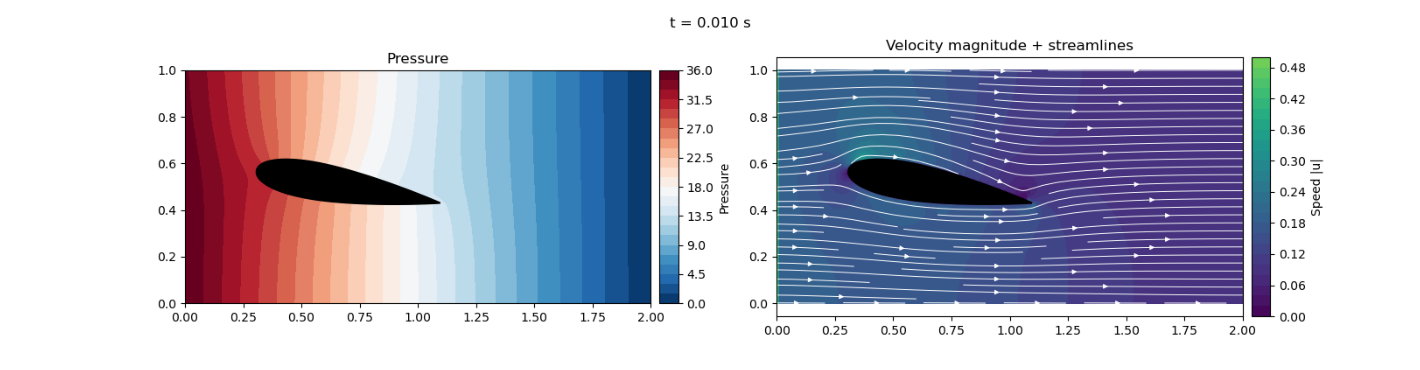

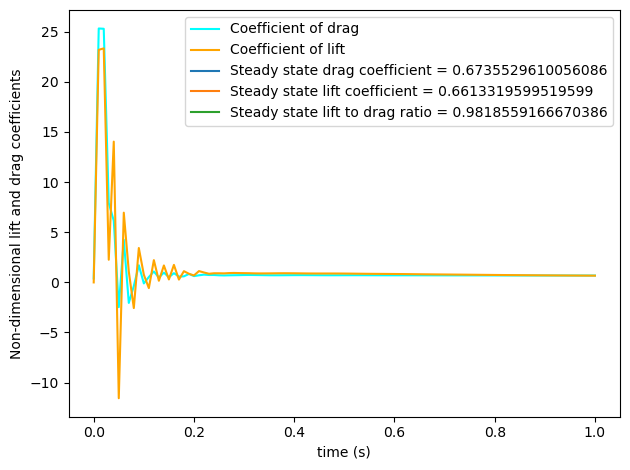

In [ ]:
# PLotting results

def run_simulation(p,u,v,U_inf,dx,dy,dx2,dy2,dt,Nx,Ny,X,Y,ref_length,kin_viscosity,shape,relaxation,tolerance,max_iterations,n_steps,print_every,save_every) : # runs the simulation in time
    print_step_every = int(round(print_every*(n_steps)/100))

    n_frames = n_steps // save_every +1 # note save_every is in frames, and +1 is for initial conditions
    snapshots = np.zeros((n_frames, 3, Ny, Nx))  # axis 0 : the frame, axis 1 : 0=p, 1=u, 2=v, axis 3 = Y, axis 4 = X

    # Save initial condition at frame 0 : 
    snapshots[0,0] = p 
    snapshots[0,1] = u 
    snapshots[0,2] = v

    for step in range(n_steps) :
        u,v,p = navier_stokes_step(p,u,v,U_inf,dx,dy,dx2,dy2,dt,Nx,Ny,kin_viscosity,shape,relaxation,tolerance,max_iterations)

        if (step+1) % save_every == 0 :
            frame = (step+1)//save_every
            snapshots[frame, 0] = p
            snapshots[frame, 1] = u
            snapshots[frame, 2] = v

        if (step+1) % print_step_every == 0 :
            print(f"progress = {print_every*(step+1)/(print_step_every)}%, time = {(step+1)*dt}")
            '''
            div = compute_divergence(u,v,dx,dy,Nx,Ny,shape)
            print(f"max divergence = {np.max(np.abs(div))}")
            max_u,max_v = np.max(np.abs(u)), np.max(np.abs(v))
            print(f"max u = {max_u}, max_v = {max_v}")
            '''
    animate(snapshots, X, Y, shape, dt, save_every)
    plot_forces(snapshots,u,v,U_inf,dx,dy,dt,Nx,Ny,kin_viscosity,shape,ref_length,save_every)

def main() : 
    p,u,v,U_inf,dx,dy,dx2,dy2,dt,denominator,Nx,Ny,X,Y,cylinder_radius,kin_viscosity,shape,relaxation,tolerance,max_iterations,n_steps = setup()
    run_simulation(p,u,v,U_inf,dx,dy,dx2,dy2,dt,Nx,Ny,X,Y,cylinder_radius,kin_viscosity,shape,relaxation,tolerance,max_iterations,n_steps,print_every=1,save_every=10)

if __name__ == "__main__" : # such that functions can be re-used in other files
    main()